Github: https://github.com/mproszewska/B-XAIC <br />
Paper: https://arxiv.org/abs/2505.22252 <br />
Datensatz: https://huggingface.co/datasets/mproszewska/B-XAIC/tree/main <br />

## Imports

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch.utils.data import Subset, WeightedRandomSampler
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import Sequential, GCN, GAT, GIN, global_add_pool
from torch_geometric.utils import to_networkx

from rdkit.Chem import BondType
from rdkit import Chem

from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors

from shapiq.graph import GraphExplainer
import networkx as nx

import copy
import random

In [2]:
seed = 123

np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)

## Load data from Huggingface

In [3]:
df = pd.read_csv("b-xaic/data.csv")
path_to_local_explamnations_sdf = "b-xaic/explanations.sdf"
print(df.shape)
print(df.columns.tolist())

(50000, 15)
['Unnamed: 0', 'ChEMBL ID', 'smiles', 'rings-count', 'rings-max', 'X', 'P', 'B', 'indole', 'PAINS', 'split_0', 'split_1', 'split_2', 'split_3', 'split_4']


In [5]:
# aus https://github.com/mproszewska/B-XAIC/blob/main/dataset.py
TASKS = ["B", "P", "X", "indole", "PAINS", "rings-count", "rings-max"]
SYMBOLS = ["C", "N", "O", "F", "Cl", "Br", "P", "S", "B", "I", "Unk"]
# Mapping: Task-Name => Property-Name für die explanations.sdf
TASK_TO_PROP = {
    "B":           "B",
    "P":           "P",
    "X":           "X",
    "indole":      "indole",
    "PAINS":       "pains",
    "rings-count": "rings",
    "rings-max":   "largest_rings",
}

| Was muss das GNN lernen? | Anforderung | Schwierigkeit |
| :--- | :--- | :--- |
| Bor (B)| einzelnes Atom finden | sehr leicht |
| Phosphor (P) | einzelnes Atom finden | sehr leicht |
| Halogene (X) | eines von mehreren Atomen finden | leicht |
| Indol (I)| konkrete Struktur erkennen | mittel |
| PAINS | viele komplexe Strukturen erkennen | schwer |
| rings-count | The model should predict if a molecule contains more than four rings. | sehr schwer |
| rings-max | Detecting large rings with more than six atoms. | sehr schwer |

In [6]:
print(f"Dataset: {len(df):,} molecules, {df['smiles'].nunique():,} unique SMILES")
print(f"Avg. atoms per molecule (proxy via SMILES length): {df['smiles'].str.len().mean():.1f} chars\n")

print("Task label distribution (% positiv))") # wie auf S.5 im paper
for task in TASKS:
    bar = "█" * int(df[task].mean() * 30)
    print(f"  {task:12s} {df[task].mean():5.1%}  {bar}")

print(f"\nSplit (split_0):")
print(df["split_0"].value_counts().to_string())

Dataset: 50,000 molecules, 50,000 unique SMILES
Avg. atoms per molecule (proxy via SMILES length): 66.9 chars

Task label distribution (% positiv))
  B             2.2%  
  P            13.2%  ███
  X            55.9%  ████████████████
  indole       36.8%  ███████████
  PAINS        32.9%  █████████
  rings-count  30.1%  █████████
  rings-max     5.7%  █

Split (split_0):
split_0
train    40000
valid     5000
test      5000


In [7]:
# Helper-funktionen aus dataset.py

def atom_label(atom):
    sym = atom.GetSymbol()
    return SYMBOLS.index(sym) if sym in SYMBOLS else len(SYMBOLS) - 1

def bond_type_to_int(bond_type):
    if bond_type == BondType.SINGLE:   return 0
    elif bond_type == BondType.DOUBLE: return 1
    elif bond_type == BondType.TRIPLE: return 2
    elif bond_type == BondType.AROMATIC: return 3
    else: return -1

def smiles_to_graph(mol):
    x = F.one_hot(
        torch.tensor([atom_label(atom) for atom in mol.GetAtoms()], dtype=torch.long),
        len(SYMBOLS),
    ).float()

    row, col, edge_labels = [], [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        row += [i, j]
        col += [j, i]
        edge_type = bond_type_to_int(bond.GetBondType())
        edge_labels += [edge_type, edge_type]

    edge_index = torch.tensor([row, col], dtype=torch.long)
    edge_attr  = torch.tensor(edge_labels, dtype=torch.long).view(-1, 1)
    return x, edge_index, edge_attr

In [8]:
# aus dataset.py
TASK = "indole"

property = TASK_TO_PROP[TASK]

splits = df[[f"split_{i}" for i in range(5)]]
ys     = torch.tensor(df[TASK].tolist()).unsqueeze(1)

dataset = []
skipped = 0

avg_density = 0

with Chem.SDMolSupplier(path_to_local_explamnations_sdf, sanitize=False) as suppl:
    for y, mol in tqdm(zip(ys, suppl), total=len(ys)):
        if mol is None:
            skipped += 1
            continue

        x, edge_index, edge_attr = smiles_to_graph(mol)

        p = mol.GetProp(property)
        expl_node_mask = torch.zeros(len(x), dtype=torch.bool)
        if p != "":
            nodes = torch.tensor([int(n) for n in p.split(",")], dtype=torch.long)
            expl_node_mask[nodes] = True

        if property not in ["B", "P", "X"]:
            p = mol.GetProp(f"{property}_edge")
            expl_edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
            if p != "":
                edges = {(int(e1), int(e2)) for e1, e2 in [e.split("#") for e in p.split(",")]}
                for i in range(edge_index.shape[1]):
                    e1, e2 = edge_index[0, i].item(), edge_index[1, i].item()
                    expl_edge_mask[i] = (e1, e2) in edges or (e2, e1) in edges
        else:
            expl_edge_mask = None
        
        graph = Data(
            x=x, edge_index=edge_index, edge_attr=edge_attr, y=y,
            expl_node_mask=expl_node_mask, expl_edge_mask=expl_edge_mask,
        )
        dataset.append(graph)
        density = 2 * graph.num_edges / (graph.num_nodes-1)*graph.num_nodes
        avg_density += density/50_000


print(f"Total number of graphs : {len(dataset)}")
print(f"Average Graph Density of Dataset : {avg_density:.2f}")

100%|██████████| 50000/50000 [00:17<00:00, 2796.84it/s]

Total number of graphs : 50000
Average Graph Density of Dataset : 154.72


In [9]:
#Splits und DataLoader aus dataset.py(get_splits), (train_model.py) 
SPLIT = 0
BATCH = 64

idx = torch.arange(len(splits))
split_col = splits[f"split_{SPLIT}"]
train_idx = idx[split_col == "train"]
val_idx   = idx[split_col == "valid"]
test_idx  = idx[split_col == "test"]

train_set = Subset(dataset, train_idx)
val_set   = Subset(dataset, val_idx)
test_set  = Subset(dataset, test_idx)

y_train        = torch.cat([dataset[i].y for i in train_idx])
class_counts   = torch.bincount(y_train)
sample_weights = (1.0 / class_counts.float())[y_train]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

loader_train_sampler = DataLoader(train_set, batch_size=BATCH, sampler=sampler)
loader_train = DataLoader(train_set, batch_size=BATCH, shuffle=True)
loader_val   = DataLoader(val_set,   batch_size=BATCH, shuffle=False)
loader_test  = DataLoader(test_set,  batch_size=BATCH, shuffle=False)

print(f"Task: {TASK}  |  Split: {SPLIT}")
print(f"Train: {len(train_set)}  Val: {len(val_set)}  Test: {len(test_set)}")

Task: indole  |  Split: 0
Train: 40000  Val: 5000  Test: 5000


## GCN, GAT, GIN definition

In [10]:
# aus train_model.py (get_model)

def get_model(model_type, num_node_features, num_classes,
              hidden_dim=32, num_layers=3, linear_dim=32):

    if model_type == "GCN":
        model = Sequential("x, edge_index, batch", [
            (GCN(num_node_features, hidden_dim,
                 num_layers=num_layers, out_channels=linear_dim),
             "x, edge_index -> x"),
            (global_add_pool, "x, batch -> x"),
            Linear(linear_dim, num_classes),
        ])

    elif model_type == "GAT":
        model = Sequential("x, edge_index, batch", [
            (GAT(num_node_features, hidden_dim,
                 num_layers=num_layers, out_channels=linear_dim,
                 act="elu", dropout=0.6),
             "x, edge_index -> x"),
            (global_add_pool, "x, batch -> x"),
            Linear(linear_dim, num_classes),
        ])

    elif model_type == "GIN":
        model = Sequential("x, edge_index, batch", [
            (GIN(num_node_features, hidden_dim,
                 num_layers=num_layers, out_channels=linear_dim,
                 norm="batch_norm"),
             "x, edge_index -> x"),
            (global_add_pool, "x, batch -> x"),
            Linear(linear_dim, num_classes),
        ])

    return model

## Training / Test functions

In [11]:
# wie in train_model.py
from sklearn.metrics import f1_score

def train(model, optimizer, dataloader, device):
    model.train()
    total_loss = 0
    for data in dataloader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, batch=data.batch)
        loss = F.cross_entropy(out, data.y)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return float(loss) / len(dataloader)


@torch.no_grad()
def test(model, dataloader, device):
    model.eval()
    ys, preds = list(), list()
    total_loss = 0
    for data in dataloader:
        data = data.to(device)
        out = model(data.x, data.edge_index, batch=data.batch)
        pred = out.argmax(dim=-1)
        ys.append(data.y.cpu())
        preds.append(pred.cpu())
        total_loss += F.cross_entropy(out, data.y)
    ys, preds = torch.cat(ys), torch.cat(preds)
    f1 = f1_score(ys, preds, average="weighted")
    return total_loss / len(dataloader), f1

## Full Training

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def full_training(
        model_type='GCN',
        num_node_features=11,
        num_classes=2,
        hidden_dim=32,
        num_layers=3,
        linear_dim=32,
        lr=0.0001,
        weight_decay=0.0001,
        warmup_epochs=10,
        epochs=100,
        save_dir='models',
    ):
    model_args = {
        "model_type":model_type,
        "num_node_features":num_node_features,
        "num_classes":num_classes,
        "hidden_dim":hidden_dim,
        "num_layers":num_layers,
        "linear_dim":linear_dim,
    }
    save_path = f"{save_dir}/bxaic/indole/best_{model_type.lower()}_{num_layers}_layered_b-xaic-{TASK}.pth"
    args = {
        "lr":lr,
        "weight_decay":weight_decay,
        "warmup_epochs":warmup_epochs,
        "epochs":epochs,
        "save_path":save_path
    }

    history = {"loss_train":[], "loss_test":[], "accuracy_train":[], "accuracy_test":[], "best_val_acc":0}

    model = get_model(**model_args).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"], weight_decay=args["weight_decay"])

    pbar = tqdm(range(1, args["epochs"] + 1))
    max_f1_train, max_f1_val, max_f1_test = 0, 0, 0
    best_state_dict = copy.deepcopy(model.state_dict())
    count = 0
    patience = 50

    for epoch in pbar:
        train(model, optimizer, loader_train_sampler, device)
        loss_train, f1_train = test(model, loader_train, device)
        loss_val, f1_val = test(model, loader_val, device)
        loss_test, f1_test = test(model, loader_test, device)
        history["loss_train"].append(loss_train)
        history["accuracy_train"].append(f1_train)
        history["loss_test"].append(loss_test)
        history["accuracy_test"].append(f1_test)
        if max_f1_val < f1_val:
            max_f1_train, max_f1_val, max_f1_test = f1_train, f1_val, f1_test
            best_state_dict = copy.deepcopy(model.state_dict())
            count = 0
        else:
            if epoch > args["warmup_epochs"]:
                count += 1
        pbar.set_description(
            f"e:{epoch} | train l:{loss_train:.4f} f1:{f1_train:.4f} | val l:{loss_val:.4f} f1:{f1_val:.4f} | test l:{loss_test:.4f} f1:{f1_test:.4f}"
        )
        if count >= patience:
            break
    pbar.set_description(f"Final {max_f1_train:.4f} {max_f1_val:.4f} {max_f1_test:.4f}")
    pbar.close()
    model.load_state_dict(best_state_dict)
    model.eval()
    _, final_f1 = test(model, loader_test, device)
    print(f"Final f1: {final_f1:.4f}")
    history["best_val_acc"] = final_f1
    torch.save(
        {
            "state_dict": model.state_dict(),
            "model_args": model_args,
            "args": args,
            "f1": final_f1,
        },
        args["save_path"],
    )
    print(f"Saved to {args['save_path']}")
    return history

In [13]:
gcn_history = {}

hidden_layers = [128, 64, 64]
for i in range(3):
    print(f"\nStarting GCN Training for {i+1} Layer Model...")
    history = full_training(model_type='GCN', num_layers=i+1, hidden_dim=hidden_layers[i], epochs=500)
    gcn_history[str(i)] = history


Starting GCN Training for 1 Layer Model...


  0%|          | 0/500 [00:00<?, ?it/s]/var/folders/1m/r99fgl292hs6n6rd6gnskp2m0000gn/T/ipykernel_177/3276719899.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  return float(loss) / len(dataloader)
e:24 | train l:0.5427 f1:0.7109 | val l:0.5516 f1:0.7027 | test l:0.5440 f1:0.7162:   5%|▍         | 24/500 [01:14<24:29,  3.09s/it]


KeyboardInterrupt: 

In [ ]:
gat_history = {}

hidden_layers = [128, 64, 64]
for i in range(3):
    print(f"\nStarting GAT Training for {i+1} Layer Model...")
    history = full_training(model_type='GAT', num_layers=i+1, hidden_dim=hidden_layers[i], epochs=500)
    gat_history[str(i)] = history


Starting GAT Training for 1 Layer Model...


e:299 | train l:0.5440 f1:0.7110 | val l:0.5499 f1:0.7101 | test l:0.5471 f1:0.7072:  60%|█████▉    | 298/500 [13:15<08:59,  2.67s/it]


Final f1: 0.7144
Saved to models/best_gat_1_layered_b-xaic-indole.pth

Starting GAT Training for 2 Layer Model...


e:86 | train l:0.6076 f1:0.6532 | val l:0.6137 f1:0.6573 | test l:0.6127 f1:0.6499:  17%|█▋        | 85/500 [06:28<31:38,  4.58s/it]


Final f1: 0.7001
Saved to models/best_gat_2_layered_b-xaic-indole.pth

Starting GAT Training for 3 Layer Model...


e:102 | train l:0.6399 f1:0.6377 | val l:0.6453 f1:0.6408 | test l:0.6464 f1:0.6367:  20%|██        | 101/500 [11:19<44:44,  6.73s/it]


Final f1: 0.6828
Saved to models/best_gat_3_layered_b-xaic-indole.pth


In [ ]:
gin_history = {}

hidden_layers = [128, 64, 64]
for i in range(3):
    print(f"\nStarting GIN Training for {i+1} Layer Model...")
    history = full_training(model_type='GIN', num_layers=i+1, hidden_dim=hidden_layers[i], epochs=500)
    gin_history[str(i)] = history


Starting GIN Training for 1 Layer Model...


e:128 | train l:0.4372 f1:0.7960 | val l:0.4401 f1:0.7948 | test l:0.4388 f1:0.7916:  25%|██▌       | 127/500 [03:57<11:36,  1.87s/it]


Final f1: 0.7924
Saved to models/best_gin_1_layered_b-xaic-indole.pth

Starting GIN Training for 2 Layer Model...


e:295 | train l:0.1700 f1:0.9436 | val l:0.1822 f1:0.9375 | test l:0.2027 f1:0.9342:  59%|█████▉    | 294/500 [14:29<10:09,  2.96s/it]


Final f1: 0.9435
Saved to models/best_gin_2_layered_b-xaic-indole.pth

Starting GIN Training for 3 Layer Model...


e:230 | train l:0.0303 f1:0.9912 | val l:0.0633 f1:0.9838 | test l:0.0679 f1:0.9809:  46%|████▌     | 229/500 [32:44<38:44,  8.58s/it]    

Final f1: 0.9816
Saved to models/best_gin_3_layered_b-xaic-indole.pth


In [14]:
def smoothing(data, window_size):
    weights = np.ones(window_size) / window_size
    return np.convolve(data, weights, mode='valid')

def plot_history(history, model_name, window_size=15):
    colors = ['orange', 'red', 'blue']

    plt.figure(figsize=(8,4))
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Training Loss {model_name}')
    for i in range(len(history.keys())):
        smoothed_train = smoothing(history[str(i)]['loss_train'], window_size)
        plt.plot(smoothed_train, color=colors[i], label=f'{i+1}-layered')
    plt.grid()
    plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(f"training_plots/losses_{model_name}_b-xaic.png", dpi=300, bbox_inches="tight")

    plt.figure(figsize=(10,5))
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Test Accuracy {model_name}')
    for i in range(len(history.keys())):
        smoothed_train = smoothing(history[str(i)]['accuracy_test'], window_size)
        plt.plot(smoothed_train, color=colors[i], label=f'{i+1}-layered')
        plt.axhline(y=history[str(i)]['best_val_acc'], color=colors[i], linestyle='--', linewidth=0.5, label=f'Best saved {i+1}-layered model: acc={history[str(i)]['best_val_acc']:.3f}')
    plt.grid()
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.savefig(f"training_plots/accuracies_{model_name}_b-xaic.png", dpi=300, bbox_inches="tight")

/var/folders/1m/r99fgl292hs6n6rd6gnskp2m0000gn/T/ipykernel_62132/1362450977.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')
/var/folders/1m/r99fgl292hs6n6rd6gnskp2m0000gn/T/ipykernel_62132/1362450977.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


NameError: name 'gat_history' is not defined

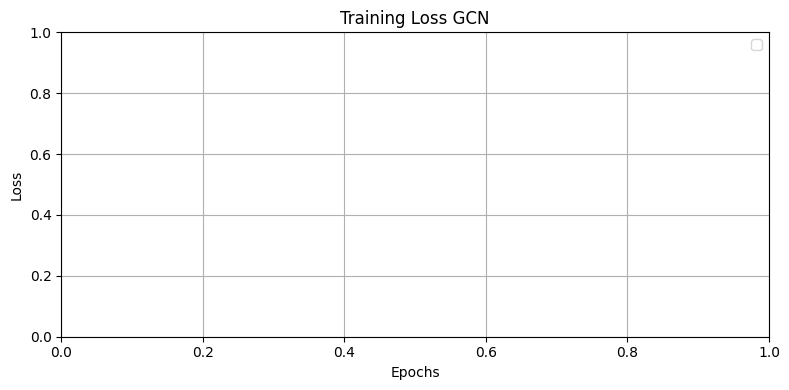

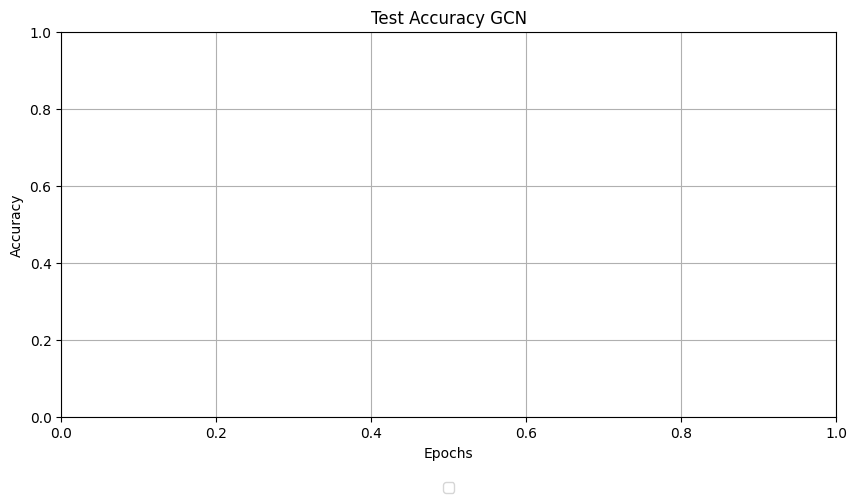

In [18]:
plot_history(gcn_history, 'GCN', 20)
plot_history(gat_history, 'GAT', 20)
plot_history(gin_history, 'GIN', 20)

## Explainations: Max-order= 1 -> Shapley values

Loading Model...
Lade ausgewählte Graphen...
Dataset-Index=63 | Prediction=1 | Nodes=65
Dataset-Index=64 | Prediction=1 | Nodes=72
Dataset-Index=67 | Prediction=0 | Nodes=24
Dataset-Index=70 | Prediction=0 | Nodes=25

--- Plotte Dataset-Index 63 (Prediction 1) ---
Computing Shapley Values...


/Users/davidluff/projects/lmu_projects/Explainable_AI_and_Trustworthy_Machine_Learning/new/shapiq/src/shapiq/explainer/validation.py:92: UserWarning: Mismatch between max_order=1 and index=k-SII. k-SII generalizes 'SV'. Setting index to 'SV'.
  validated_index = validate_index(index, max_order)


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/306816 [00:00<?, ? coalition/s]


--- Plotte Dataset-Index 64 (Prediction 1) ---
Computing Shapley Values...


...

Evaluating game:   0%|          | 0/12928 [00:00<?, ? coalition/s]


--- Plotte Dataset-Index 70 (Prediction 0) ---
Computing Shapley Values...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/366080 [00:00<?, ? coalition/s]


Gespeichert unter: results/b-xaic_explanation_selected_graphs_indole_GCN_maxOrder=1.png


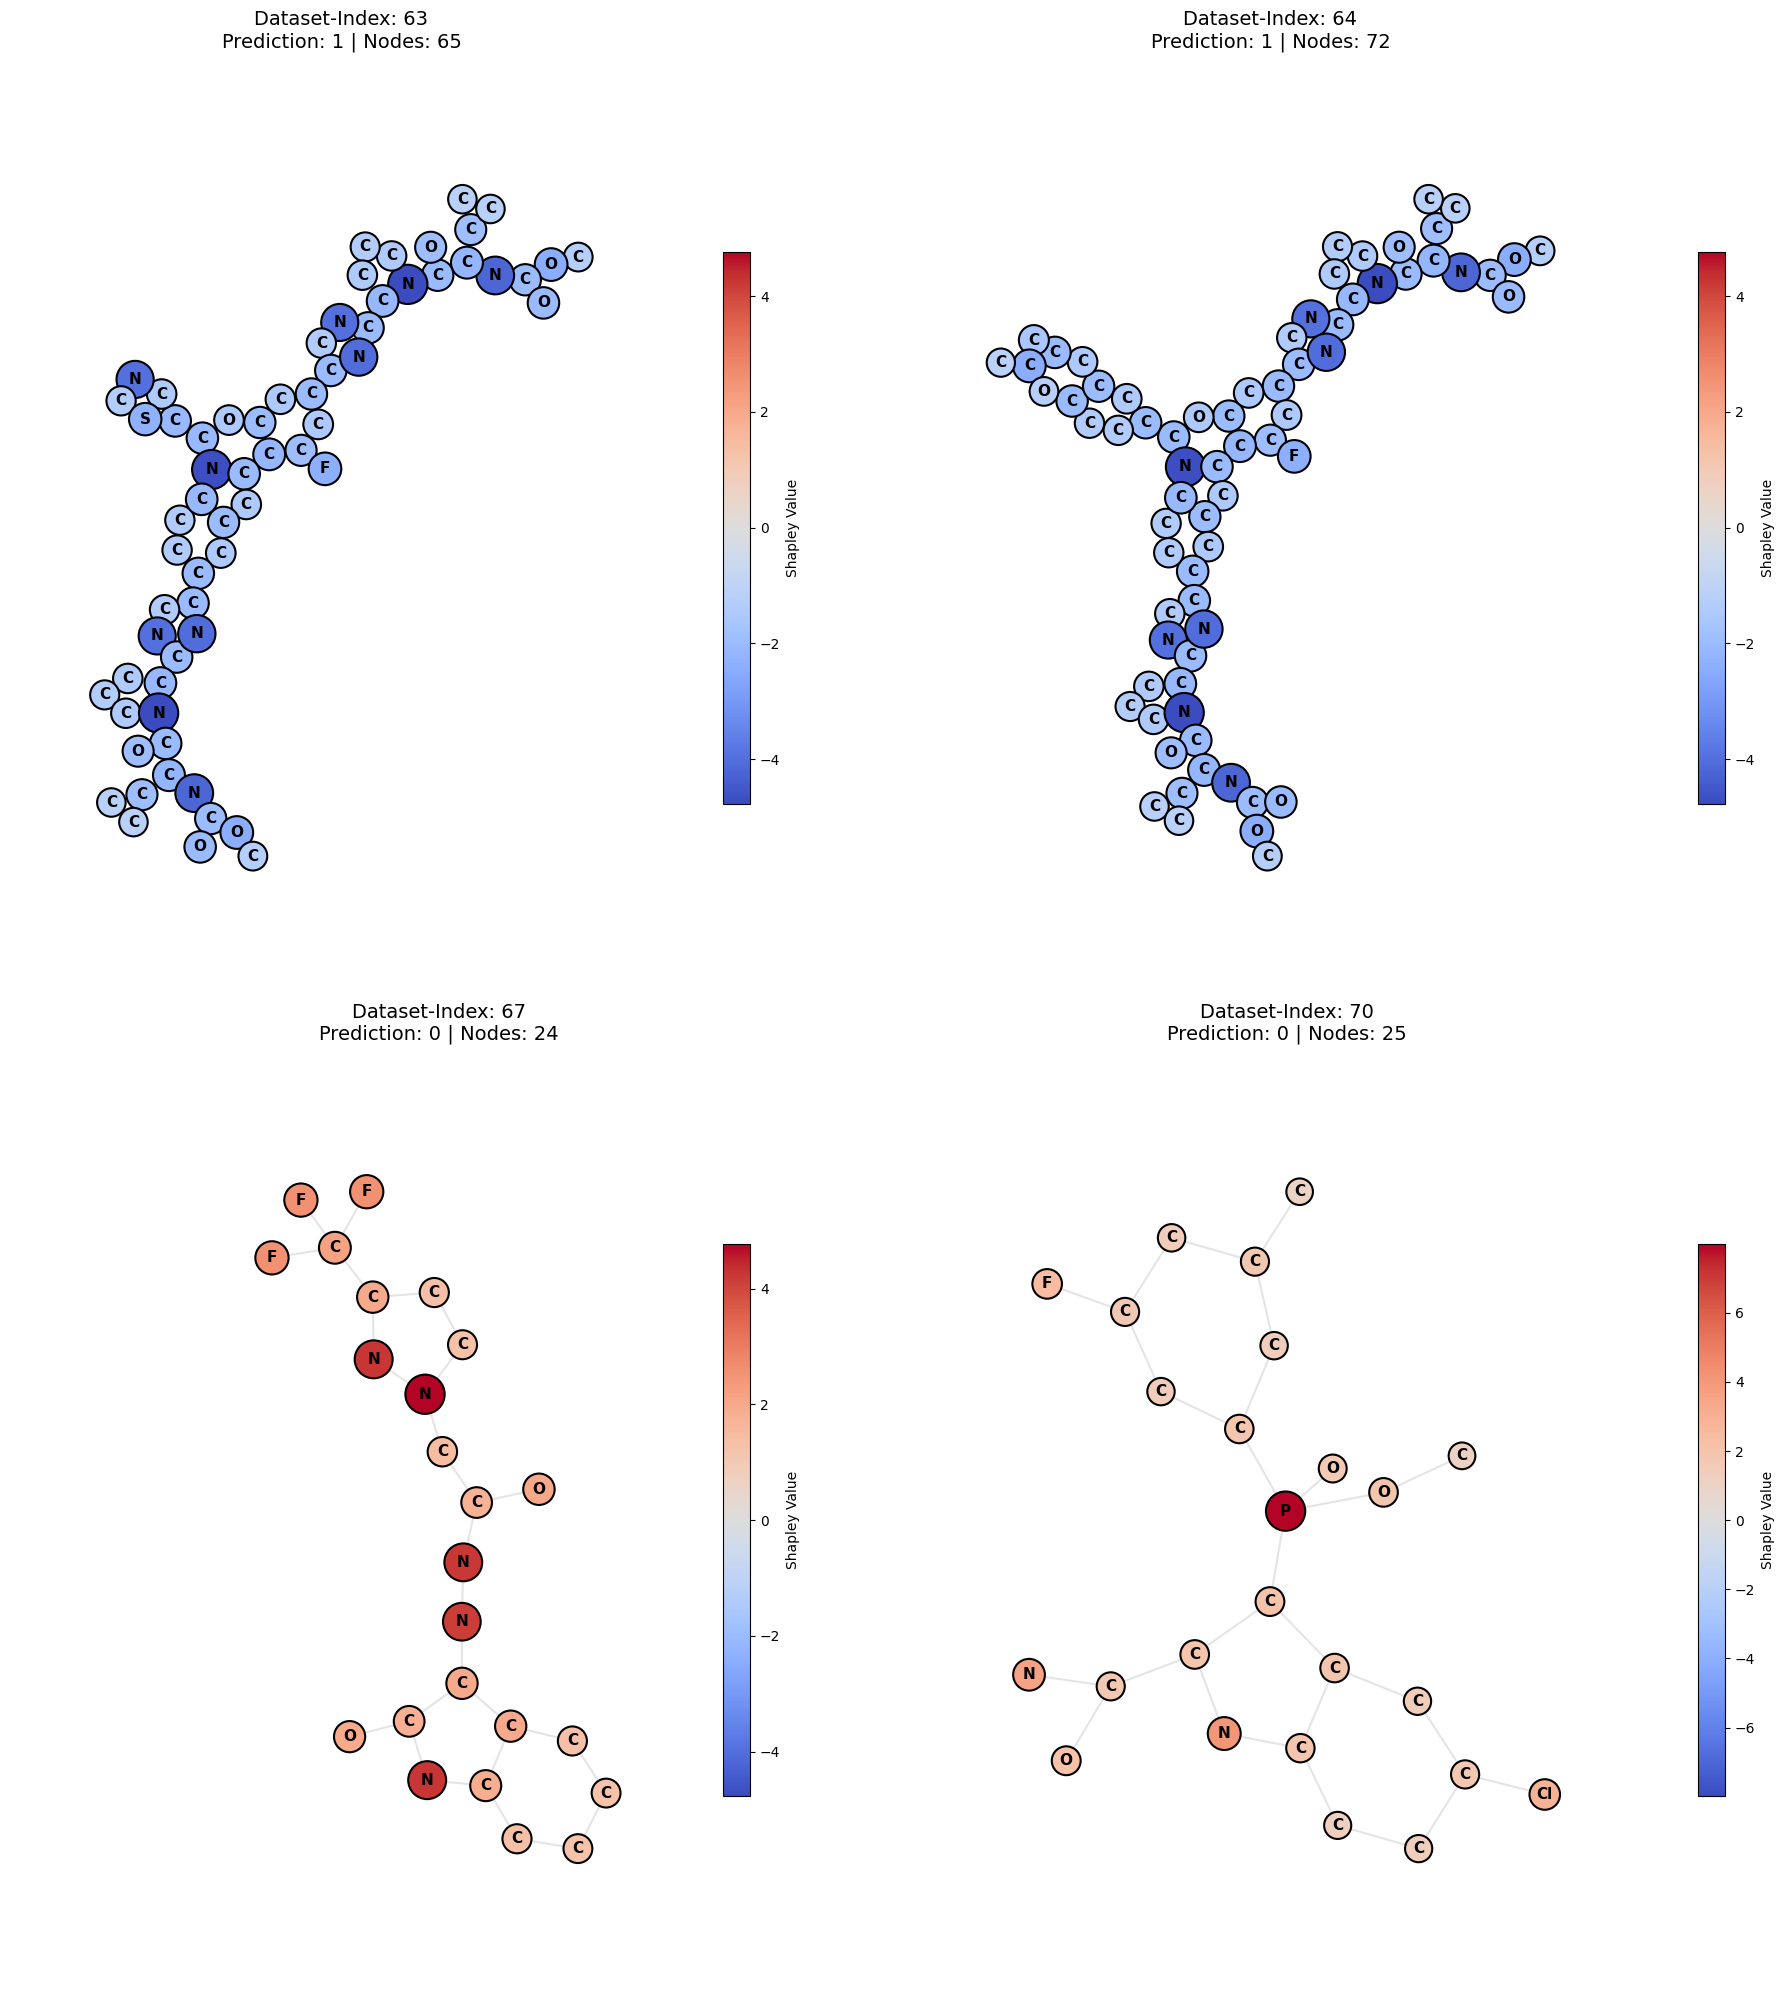

In [15]:
def explanation_graph_plot_shapley_only(
    interaction_values,
    edge_index: torch.Tensor,
    atom_labels: list,
    num_nodes: int,
    pos: dict,
    ax: plt.Axes = None,
):
    if ax is None:
        ax = plt.gca()

    node_values = {}
    for subset, idx in interaction_values.interaction_lookup.items():
        if len(subset) != 1:
            continue
        node_values[subset[0]] = float(interaction_values.values[idx])

    node_x = [pos[n][0] for n in range(num_nodes)]
    node_y = [pos[n][1] for n in range(num_nodes)]
    node_vals = [node_values.get(n, 0.0) for n in range(num_nodes)]

    abs_max = max(abs(v) for v in node_vals) if node_vals else 1e-9
    abs_max = max(abs_max, 1e-9)

    cmap = mpl.colormaps['coolwarm']
    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    edge_index_np = edge_index.cpu().numpy()
    physical_edges = set()
    for i in range(edge_index_np.shape[1]):
        u, v = sorted([int(edge_index_np[0, i]), int(edge_index_np[1, i])])
        physical_edges.add((u, v))

    for u, v in physical_edges:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='lightgray', linewidth=1.5, alpha=0.6, zorder=1)

    node_colors = [cmap(norm(v)) for v in node_vals]
    node_sizes = [300 + 500 * (abs(v) / abs_max) for v in node_vals]

    sc = ax.scatter(
        node_x, node_y,
        s=node_sizes, c=node_colors,
        edgecolors='black', linewidths=1.5, zorder=2
    )

    for n in range(num_nodes):
        ax.text(pos[n][0], pos[n][1], str(atom_labels[n]),
                fontsize=11, fontweight='bold', color='black',
                ha='center', va='center', zorder=3)

    ax.axis('off')
    ax.margins(x=0.2, y=0.2)
    ax.set_aspect('equal')

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.6, label="Shapley Value")

    return sc


def decode_atoms(feature_matrix: torch.Tensor):
    labels = []
    atom_indices = torch.argmax(feature_matrix, dim=1).cpu().numpy()
    for idx in atom_indices:
        if int(idx) < len(SYMBOLS):
            labels.append(SYMBOLS[int(idx)])
        else:
            labels.append('?')
    return labels

print("Loading Model...")
model = get_model('GCN', 11, 2, hidden_dim=64, num_layers=3)
checkpoint = torch.load(
    f"models/best_gcn_3_layered_b-xaic-{TASK}.pth",
    map_location=device,
    weights_only=False
)
model.load_state_dict(checkpoint["state_dict"], strict=True)
model.eval()
model.num_layers = 3

explainer = GraphExplainer(
    model,
    baseline_strategy='zeros',
    max_order=1,
    l_shapley_max_budget=500000,
    verbose=True
)

# ======================================================
# Dataset-Indizes der zu plottenden Graphen
# ======================================================
GRAPH_INDICES = [
    63,
    64,
    67,
    70,
]
# ======================================================

selected_graphs = []

print("Lade ausgewählte Graphen...")

for dataset_idx in GRAPH_INDICES:

    x_graph = dataset[dataset_idx]
    x_graph = x_graph.to(device)

    with torch.no_grad():
        out = model(x_graph.x, x_graph.edge_index, x_graph.batch)
        pred = int(out.argmax(dim=1)[0].item())

    atom_labels = decode_atoms(x_graph.x)

    selected_graphs.append(
        (dataset_idx, x_graph, pred, atom_labels)
    )

    print(
        f"Dataset-Index={dataset_idx} | "
        f"Prediction={pred} | "
        f"Nodes={x_graph.num_nodes}"
    )

# Grid automatisch bestimmen
n_graphs = len(selected_graphs)
n_cols = 2
n_rows = (n_graphs + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10 * n_cols, 10 * n_rows)
)

axes_flat = axes.flatten() if n_graphs > 1 else [axes]

for i, (dataset_idx, x_graph, pred, atom_labels) in enumerate(selected_graphs):

    print(
        f"\n--- Plotte Dataset-Index {dataset_idx} "
        f"(Prediction {pred}) ---"
    )

    print("Computing Shapley Values...")
    interaction_values = explainer.explain(x_graph)

    num_nodes = (
        x_graph.num_nodes
        if hasattr(x_graph, "num_nodes")
        else x_graph.x.shape[0]
    )

    nx_graph = to_networkx(x_graph, to_undirected=True)
    pos = nx.kamada_kawai_layout(nx_graph)

    ax = axes_flat[i]

    explanation_graph_plot_shapley_only(
        interaction_values=interaction_values,
        edge_index=x_graph.edge_index,
        atom_labels=atom_labels,
        num_nodes=num_nodes,
        pos=pos,
        ax=ax,
    )

    ax.set_title(
        f"Dataset-Index: {dataset_idx}\n"
        f"Prediction: {pred} | Nodes: {num_nodes}",
        fontsize=14,
        pad=15,
    )

for j in range(len(selected_graphs), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()

output_file = (
    f"results/b-xaic_explanation_selected_graphs_{TASK}_GCN_maxOrder=1.png"
)

plt.savefig(output_file, bbox_inches="tight")

print(f"\nGespeichert unter: {output_file}")

## Explanations: Order 2

Loading Model...
Lade ausgewählte Graphen...
Dataset-Index=142 | Prediction=1 | Nodes=31
Dataset-Index=17 | Prediction=0 | Nodes=35
Dataset-Index=100 | Prediction=1 | Nodes=33
Dataset-Index=67 | Prediction=0 | Nodes=24

--- Plotte Dataset-Index 142 (Prediction 1) ---
Computing Order-2 Shapley Values...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/60416 [00:00<?, ? coalition/s]


--- Plotte Dataset-Index 17 (Prediction 0) ---
Computing Order-2 Shapley Values...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

...

Evaluating game:   0%|          | 0/41216 [00:00<?, ? coalition/s]


--- Plotte Dataset-Index 67 (Prediction 0) ---
Computing Order-2 Shapley Values...


Evaluating game:   0%|          | 0/1 [00:00<?, ? coalition/s]

Evaluating game:   0%|          | 0/12928 [00:00<?, ? coalition/s]


Gespeichert unter: results/b-xaic_explanation_selected_graphs_order2_indole_GCN.png


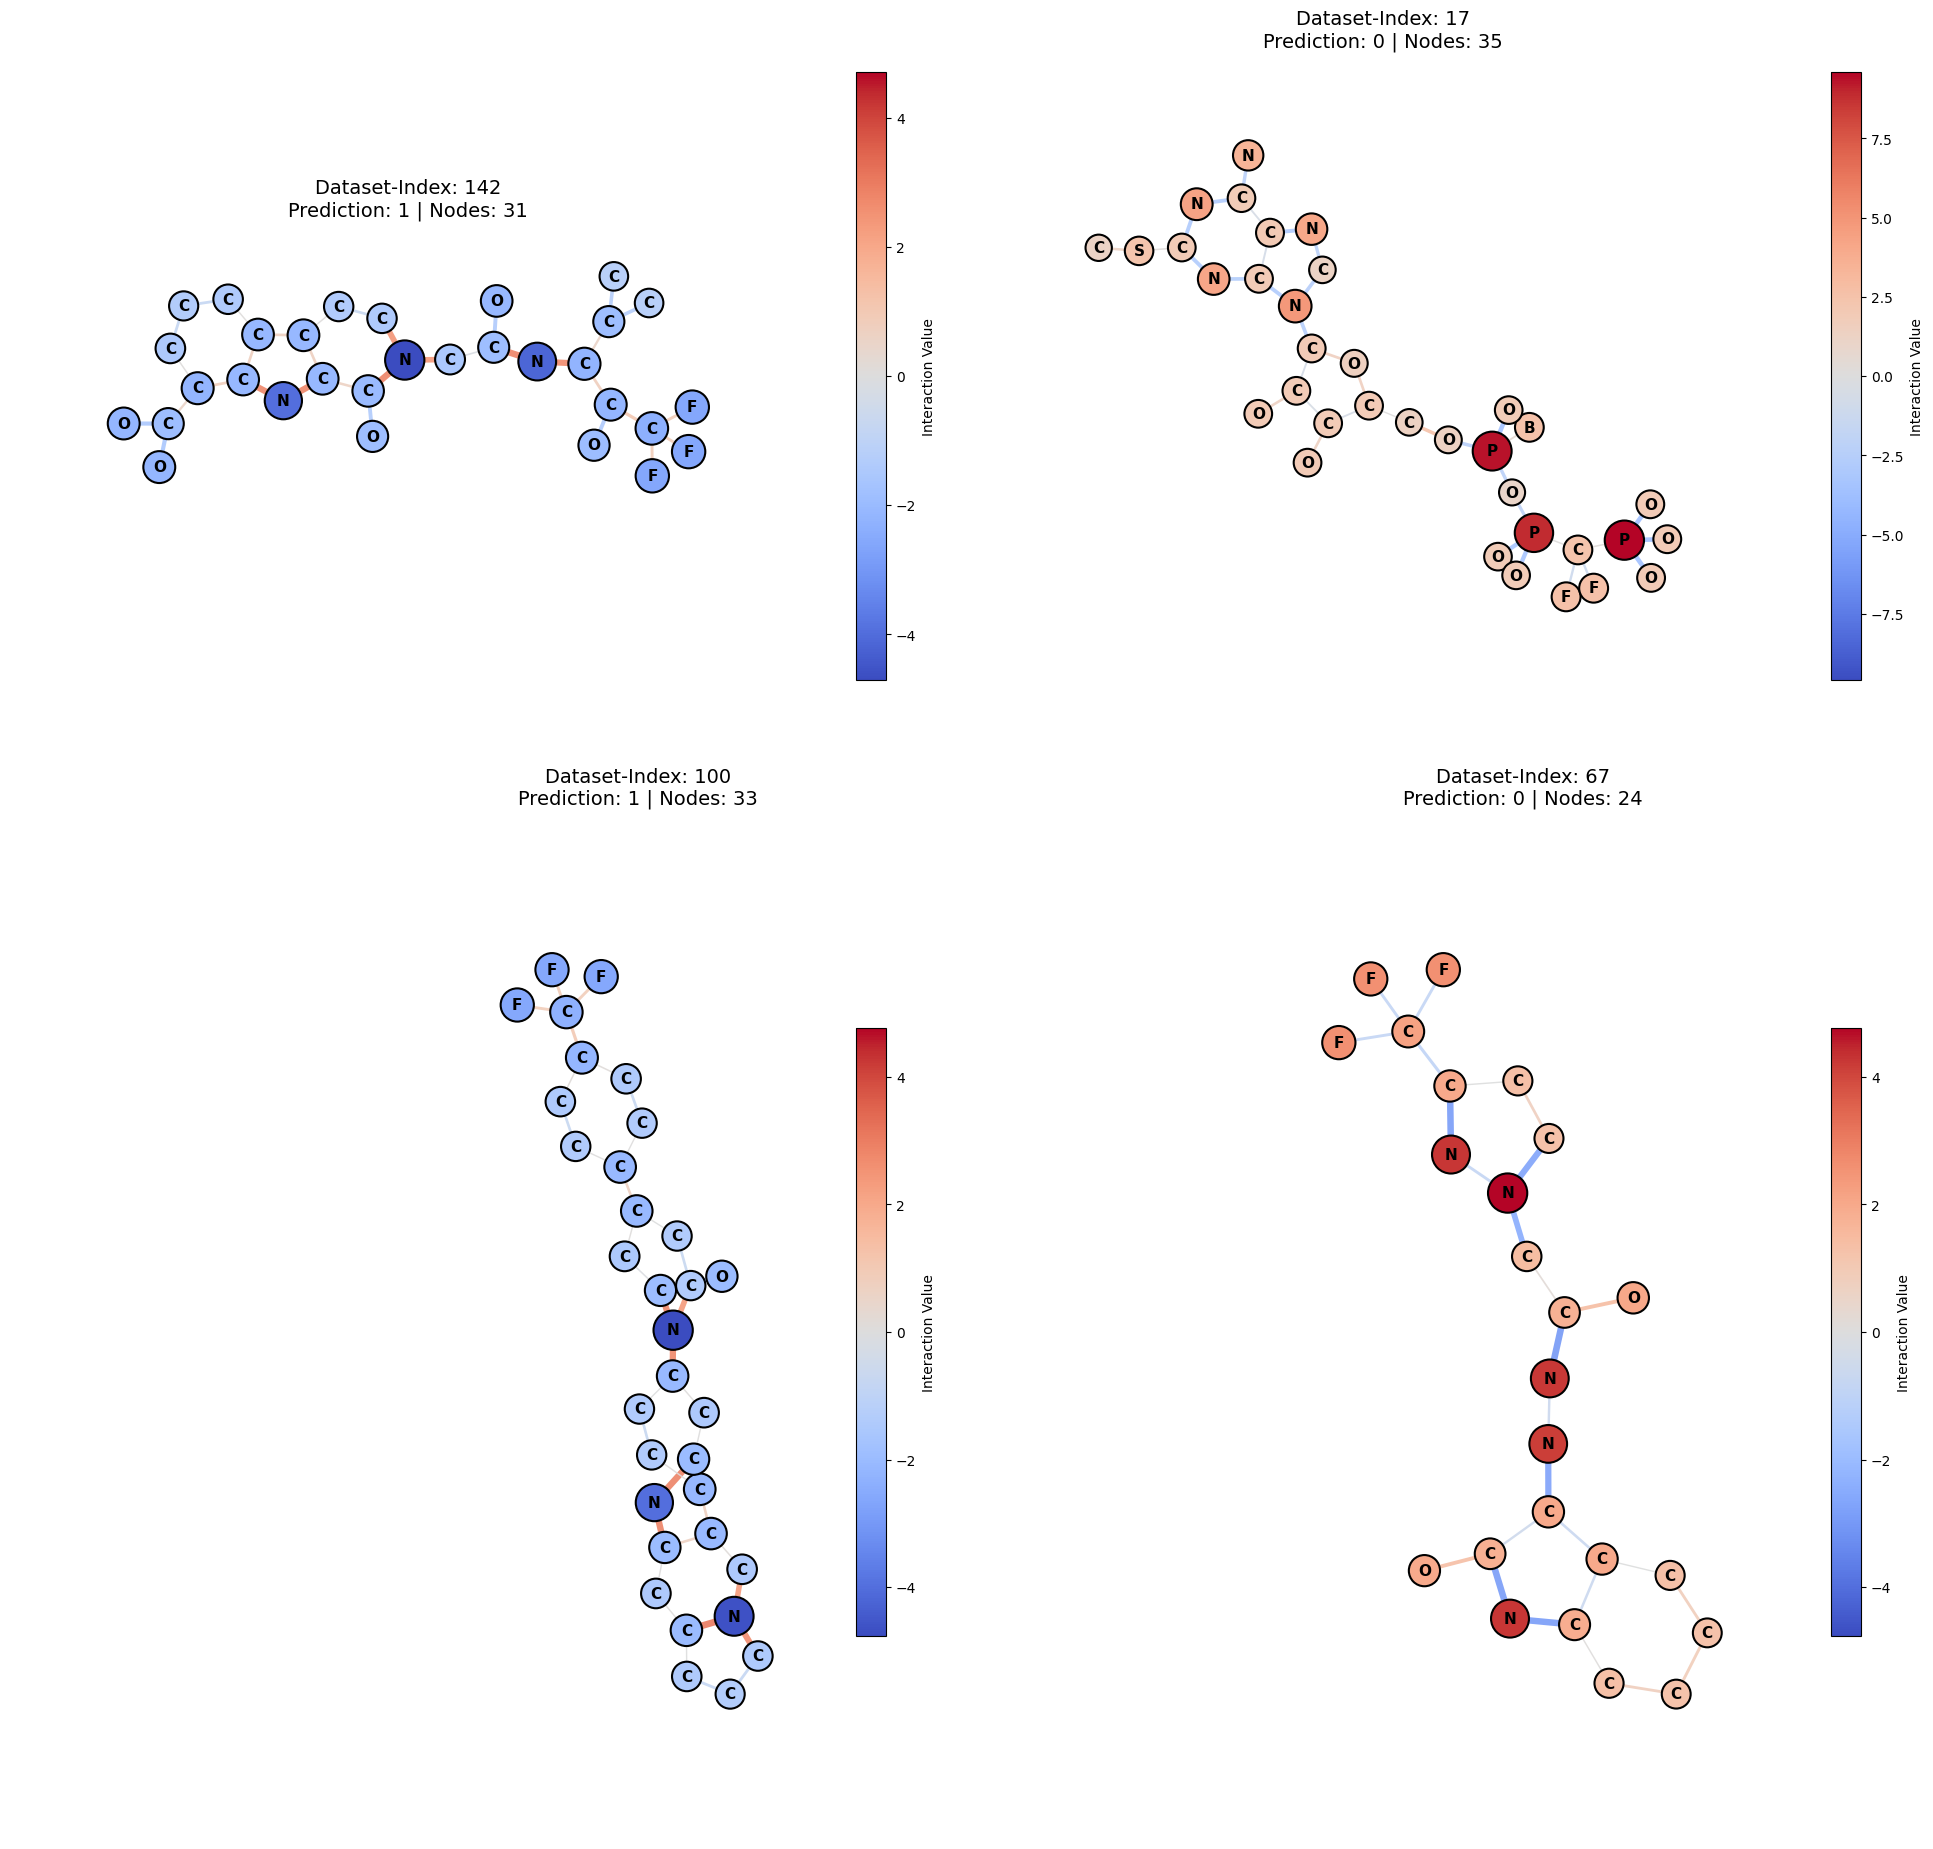

In [16]:
def explanation_graph_plot_order2(
    interaction_values,
    edge_index,
    atom_labels,
    num_nodes,
    pos,
    ax=None,
):
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import matplotlib.colors as mcolors
 
    if ax is None:
        ax = plt.gca()
 
    node_values = {}
    edge_values = {}
 
    for subset, idx in interaction_values.interaction_lookup.items():
        value = float(interaction_values.values[idx])
 
        if len(subset) == 1:
            node_values[subset[0]] = value
        elif len(subset) == 2:
            u, v = sorted(subset)
            edge_values[(u, v)] = value
 
    node_x = [pos[n][0] for n in range(num_nodes)]
    node_y = [pos[n][1] for n in range(num_nodes)]
    node_vals = [node_values.get(n, 0.0) for n in range(num_nodes)]
 
    edge_index_np = edge_index.cpu().numpy()
    physical_edges = set()
    for i in range(edge_index_np.shape[1]):
        u, v = sorted([int(edge_index_np[0, i]), int(edge_index_np[1, i])])
        physical_edges.add((u, v))
 
    edge_vals = [edge_values.get(e, 0.0) for e in physical_edges]
    all_vals = node_vals + edge_vals
    abs_max = max(max(abs(v) for v in all_vals), 1e-9)
 
    cmap = mpl.colormaps["coolwarm"]
    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
 
    for u, v in physical_edges:
        val = edge_values.get((u, v), 0.0)
        lw = 1 + 6 * abs(val) / abs_max
        ax.plot([pos[u][0], pos[v][0]],
                [pos[u][1], pos[v][1]],
                color=cmap(norm(val)),
                linewidth=lw,
                alpha=0.9,
                zorder=1)
 
    node_colors = [cmap(norm(v)) for v in node_vals]
    node_sizes = [300 + 500 * abs(v) / abs_max for v in node_vals]
 
    sc = ax.scatter(node_x,node_y,s=node_sizes,c=node_colors,
                    edgecolors="black",linewidths=1.5,zorder=2)
 
    for n in range(num_nodes):
        ax.text(pos[n][0], pos[n][1], str(atom_labels[n]),
                ha="center", va="center", fontsize=11,
                fontweight="bold", zorder=3)
 
    ax.axis("off")
    ax.set_aspect("equal")
    ax.margins(0.2)
 
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.6, label="Interaction Value")
    return sc
 
 
print("Loading Model...")
model = get_model('GCN', 11, 2, hidden_dim=64, num_layers=3)
checkpoint = torch.load(
    f"models/best_gcn_3_layered_b-xaic-{TASK}.pth",
    map_location=device,
    weights_only=False
)
model.load_state_dict(checkpoint["state_dict"], strict=True)
model.eval()
model.num_layers = 3
 
explainer = GraphExplainer(
    model,
    baseline_strategy='zeros',
    max_order=2,
    l_shapley_max_budget=500000,
    verbose=True
)
 
# ======================================================
# Dataset-Indizes der zu plottenden Graphen
# ======================================================
 
GRAPH_INDICES = [
    142,
    17,
    100,
    67,
]
 
# ======================================================
 
selected_graphs = []
 
print("Lade ausgewählte Graphen...")
 
for dataset_idx in GRAPH_INDICES:
 
    x_graph = dataset[dataset_idx]
    x_graph = x_graph.to(device)
 
    with torch.no_grad():
        out = model(x_graph.x, x_graph.edge_index, x_graph.batch)
        pred = int(out.argmax(dim=1)[0].item())
 
    atom_labels = decode_atoms(x_graph.x)
 
    selected_graphs.append(
        (dataset_idx, x_graph, pred, atom_labels)
    )
 
    print(
        f"Dataset-Index={dataset_idx} | "
        f"Prediction={pred} | "
        f"Nodes={x_graph.num_nodes}"
    )
 
# ------------------------------------------------------
# Grid automatisch bestimmen
# ------------------------------------------------------
 
n_graphs = len(selected_graphs)
n_cols = 2
n_rows = (n_graphs + n_cols - 1) // n_cols
 
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10 * n_cols, 10 * n_rows)
)
 
axes_flat = axes.flatten() if n_graphs > 1 else [axes]
 
for i, (dataset_idx, x_graph, pred, atom_labels) in enumerate(selected_graphs):
 
    print(
        f"\n--- Plotte Dataset-Index {dataset_idx} "
        f"(Prediction {pred}) ---"
    )
 
    print("Computing Order-2 Shapley Values...")
 
    interaction_values = explainer.explain(x_graph)
 
    num_nodes = (
        x_graph.num_nodes
        if hasattr(x_graph, "num_nodes")
        else x_graph.x.shape[0]
    )
 
    nx_graph = to_networkx(
        x_graph,
        to_undirected=True
    )
 
    pos = nx.kamada_kawai_layout(nx_graph)
 
    ax = axes_flat[i]
 
    explanation_graph_plot_order2(
        interaction_values=interaction_values,
        edge_index=x_graph.edge_index,
        atom_labels=atom_labels,
        num_nodes=num_nodes,
        pos=pos,
        ax=ax,
    )
 
    ax.set_title(
        f"Dataset-Index: {dataset_idx}\n"
        f"Prediction: {pred} | Nodes: {num_nodes}",
        fontsize=14,
        pad=15,
    )
 
# ------------------------------------------------------
# Leere Subplots entfernen
# ------------------------------------------------------
 
for j in range(len(selected_graphs), len(axes_flat)):
    fig.delaxes(axes_flat[j])
 
plt.tight_layout()
 
output_file = (
    f"results/b-xaic_explanation_selected_graphs_order2_{TASK}_GCN.png"
)
 
plt.savefig(
    output_file,
    bbox_inches="tight"
)
 
print(f"\nGespeichert unter: {output_file}")